In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
dataset = pd.read_csv(r"D:\Study\Credit-Card-Fraud-Detection-System\data\creditcard.csv")

In [3]:
dataset.shape

(284807, 31)

In [4]:
dataset.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
print("Missing values: ", dataset.isnull().sum().sum())

Missing values:  0


In [7]:
pd.set_option('display.float_format', lambda x:'%.6f'%x)

In [8]:
print("Basic Stats: ")
dataset.describe()

Basic Stats: 


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,...,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000
mean,94813.859575,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,...,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,88.349619,0.001727
std,47488.145955,1.958696,1.651309,1.516255,1.415869,1.380247,1.332271,1.237094,1.194353,1.098632,...,0.734524,0.725702,0.624460,0.605647,0.521278,0.482227,0.403632,0.330083,250.120109,0.041527
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54201.500000,-0.920373,-0.598550,-0.890365,-0.848640,-0.691597,-0.768296,-0.554076,-0.208630,-0.643098,...,-0.228395,-0.542350,-0.161846,-0.354586,-0.317145,-0.326984,-0.070840,-0.052960,5.600000,0.000000
50%,84692.000000,0.018109,0.065486,0.179846,-0.019847,-0.054336,-0.274187,0.040103,0.022358,-0.051429,...,-0.029450,0.006782,-0.011193,0.040976,0.016594,-0.052139,0.001342,0.011244,22.000000,0.000000
75%,139320.500000,1.315642,0.803724,1.027196,0.743341,0.611926,0.398565,0.570436,0.327346,0.597139,...,0.186377,0.528554,0.147642,0.439527,0.350716,0.240952,0.091045,0.078280,77.165000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


### Class distribution(fraud vs legit)

In [9]:
count = dataset["Class"].value_counts()
print("Note:\n O represents legitimate while 1 represents fraud:")
print(count)
print("\n Fraud rate: ", count[1]/count.sum()*100, "%")

Note:
 O represents legitimate while 1 represents fraud:
Class
0    284315
1       492
Name: count, dtype: int64

 Fraud rate:  0.1727485630620034 %


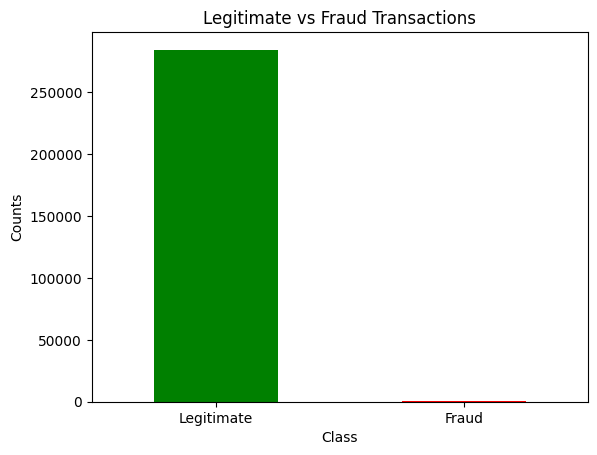

In [10]:
count.plot(kind = "bar", color = ['green', 'red'])
plt.xticks([0, 1],['Legitimate', 'Fraud'], rotation = 0)
plt.title('Legitimate vs Fraud Transactions')
plt.ylabel('Counts')
plt.show()

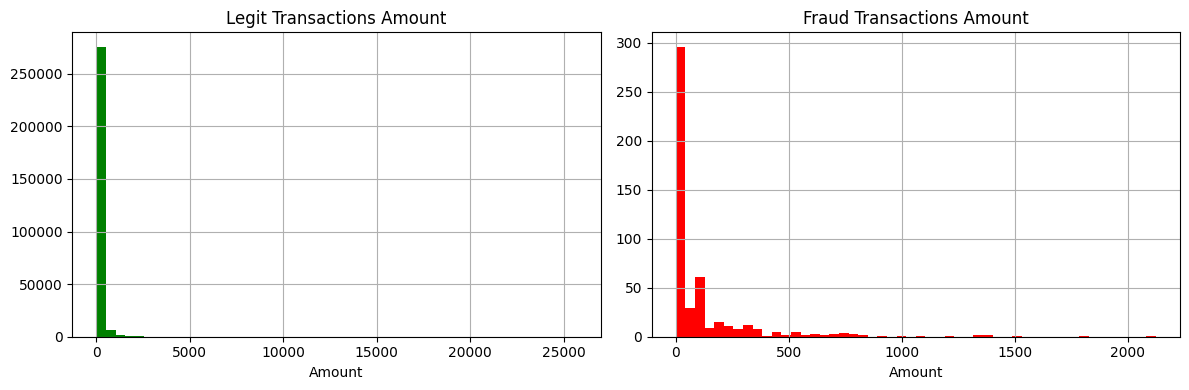

In [11]:
Legit = dataset[dataset['Class']==0]
Fraud = dataset[dataset['Class']==1]
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(Legit['Amount'], bins= 50, color='green')
plt.title('Legit Transactions Amount')
plt.xlabel('Amount')
plt.grid(True)

plt.subplot(1,2,2)
plt.hist(Fraud['Amount'], bins= 50, color='red')
plt.title('Fraud Transactions Amount')
plt.xlabel('Amount')
plt.tight_layout()
plt.grid(True)
plt.show()

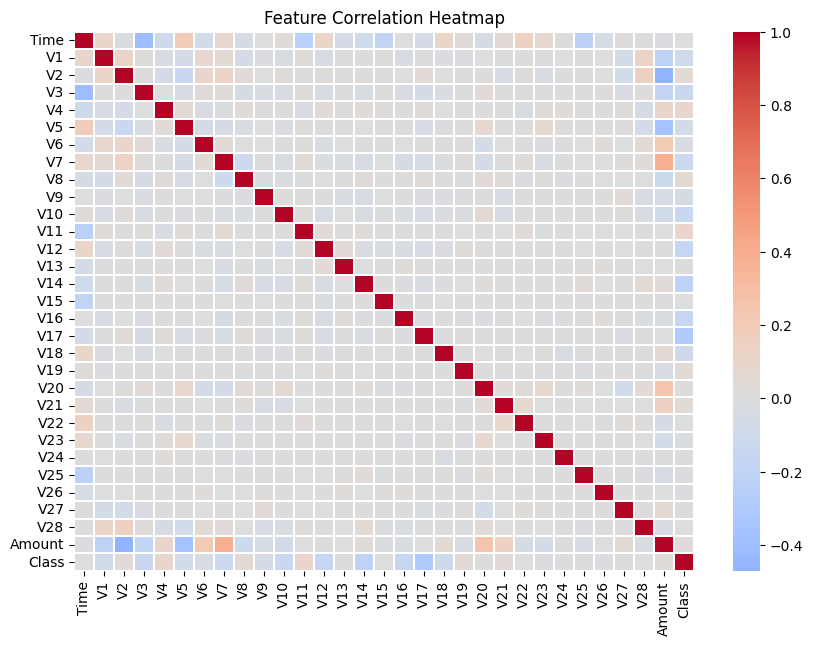

In [12]:
plt.figure(figsize=(10,7))
sample = dataset.sample(10000, random_state=42)
sns.heatmap(sample.corr(), cmap='coolwarm', linewidths=0.1, center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [13]:
sample.cov()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,2231127457.516135,9943.112400,-1766.890280,-29109.748049,-6848.151812,13047.011628,-5210.646947,4713.591615,-2741.384548,12.801627,...,1758.081036,4831.355066,2065.122760,-432.656421,-5639.217673,-1112.276946,244.740782,-128.000170,-218063.005556,1.248353
V1,9943.112400,4.183049,0.406802,0.039249,-0.082118,-0.195387,0.228816,0.134611,-0.151298,-0.046245,...,-0.010671,0.011037,-0.012947,-0.004622,-0.006784,-0.003837,-0.059102,0.074298,-99.881129,-0.007833
V2,-1766.890280,0.406802,3.249031,0.011656,-0.163974,-0.379910,0.225279,0.275879,0.063172,-0.009413,...,-0.039414,0.021098,-0.041264,-0.010381,-0.006767,0.000027,-0.052972,0.087988,-194.778892,0.002669
V3,-29109.748049,0.039249,0.011656,2.275665,-0.003487,-0.068476,0.054830,0.032695,-0.092620,-0.038453,...,-0.015287,0.004347,0.004111,-0.006258,0.003672,0.007807,-0.016814,0.006557,-62.184487,-0.008194
V4,-6848.151812,-0.082118,-0.163974,-0.003487,1.967360,0.088096,-0.061713,-0.022828,0.044609,0.025305,...,0.003282,-0.028220,0.023277,0.017200,0.001341,-0.008624,0.003682,-0.023531,32.040590,0.005046
V5,13047.011628,-0.195387,-0.379910,-0.068476,0.088096,2.080882,-0.128629,-0.093800,-0.054532,-0.000869,...,0.002342,0.011568,0.068185,0.006915,0.002253,-0.004649,0.008205,-0.037239,-120.917065,-0.004477
V6,-5210.646947,0.228816,0.225279,0.054830,-0.061713,-0.128629,1.809276,0.072769,0.000485,-0.004297,...,-0.004225,-0.007845,-0.016401,-0.004417,-0.000904,0.013354,-0.001090,0.023749,62.064978,-0.001580
V7,4713.591615,0.134611,0.275879,0.032695,-0.022828,-0.093800,0.072769,1.448114,-0.145948,-0.006725,...,-0.005392,0.020235,-0.021237,-0.004002,-0.001500,-0.001632,0.003498,0.011076,105.120407,-0.006237
V8,-2741.384548,-0.151298,0.063172,-0.092620,0.044609,-0.054532,0.000485,-0.145948,1.211768,-0.023368,...,0.014965,-0.017184,0.006629,-0.012884,0.006892,-0.000777,-0.000349,-0.000179,-27.651452,0.002554
V9,12.801627,-0.046245,-0.009413,-0.038453,0.025305,-0.000869,-0.004297,-0.006725,-0.023368,1.199930,...,-0.022922,0.005013,-0.004437,0.006826,0.001212,0.004566,0.015011,-0.013966,-11.546298,-0.002636


## Key Observations
- Dataset has ~284k transactions, only ~0.17% are fraud → heavily imbalanced
- Features V1–V28 are already PCA-transformed (anonymized)
- Amount and Time are the only raw features
- Fraud transactions tend to be smaller amounts
- We'll need SMOTE to handle the class imbalance